## 1. Libraries & Configuration

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

## 2. Dataset Importation

In [103]:
# %%
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"

df = pd.read_csv(url)

## 3. Data cleaning & Data Quality 

### 3.1. Initial Checking

In [104]:
# Target analsyis:
# - There is no null values
# - There is no change in the definition during the time
# - 37.04 % of canceling

target = "is_canceled"

summary = df[target].value_counts().to_frame("Total")
summary["%"] = df[target].value_counts(normalize=True).round(4)
summary

,Total,%
is_canceled,,
0,75166,0.6296
1,44224,0.3704


In [105]:
df.head(2).T

,0,1
hotel,Resort Hotel,Resort Hotel
is_canceled,0,0
lead_time,342,737
arrival_date_year,2015,2015
arrival_date_month,July,July
arrival_date_week_number,27,27
arrival_date_day_of_month,1,1
stays_in_weekend_nights,0,0
stays_in_week_nights,0,0
adults,2,2


In [106]:
# Checking types of columns:
# - agent and company -> must be categorical columns
# - reservation_status_date -> must be date type
# - arrival_date_X -> must be categorical << PERGUNTAR

df["agent"] = df["agent"].astype("string")
df["company"] = df["company"].astype("string")

df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])

df.dtypes

hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                 float64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type  

In [107]:
# Standarizing dataset
# - Columns and categorical columns with string normalization

df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

categorical_columns = list(df.dtypes[df.dtypes == "object"].index)
numerical_columns = list(df.dtypes[df.dtypes != "object"].index)

for col in categorical_columns:
    df[col] = df[col].str.lower().str.strip().str.replace(" ", "_")

### 3.2. NULL values

In [108]:
# Checking null values
# - children: 4
# - country: 488
# - agent: 16.340
# - company: 112.593

df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [109]:
null_col = ["children", "country", "agent", "company"]

for col in null_col:
    print(f"Coluna: {col} | Valores únicos = {df[col].nunique()}")
    df_temp = df[col].value_counts(dropna=False).head(5).to_frame("Total")
    df_temp["%"] = (df[col].value_counts(normalize=True, dropna=False).head(5)).round(4)
    display(df_temp)
    print()

Coluna: children | Valores únicos = 5


,Total,%
children,,
0.0,110796,0.9280
1.0,4861,0.0407
2.0,3652,0.0306
3.0,76,0.0006
NaN,4,0.0000



Coluna: country | Valores únicos = 177


,Total,%
country,,
prt,48590,0.4070
gbr,12129,0.1016
fra,10415,0.0872
esp,8568,0.0718
deu,7287,0.0610



Coluna: agent | Valores únicos = 333


,Total,%
agent,,
9.0,31961,0.2677
<NA>,16340,0.1369
240.0,13922,0.1166
1.0,7191,0.0602
14.0,3640,0.0305



Coluna: company | Valores únicos = 352


,Total,%
company,,
<NA>,112593,0.9431
40.0,927,0.0078
223.0,784,0.0066
67.0,267,0.0022
45.0,250,0.0021


In [110]:
# - children: 4 -> Input of mode, it is very low percentual (4/119.000) ~0.003%
# - country: 488 -> Input "unknown", it is a information.
# - agent: 16.340 -> Input "no_agency", it is a information.
# - company: 112.593 -> Input "no_company", it is a information.

mode = df["children"].mode()[0]

df["children"] = df["children"].fillna(mode)
df["country"] = df["country"].fillna("unknown")
df["agent"] = df["agent"].fillna("no_agency")
df["company"] = df["company"].fillna("no_company")

df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

### 3.3. Outliers

In [ ]:
# Outliers and wrong informations
# - Apparently there's nothing catching attention

df.describe().T

,count,mean,min,25%,50%,75%,max,std
is_canceled,119390.0,0.370416,0.0,0.0,0.0,1.0,1.0,0.482918
lead_time,119390.0,104.011416,0.0,18.0,69.0,160.0,737.0,106.863097
arrival_date_year,119390.0,2016.156554,2015.0,2016.0,2016.0,2017.0,2017.0,0.707476
arrival_date_week_number,119390.0,27.165173,1.0,16.0,28.0,38.0,53.0,13.605138
arrival_date_day_of_month,119390.0,15.798241,1.0,8.0,16.0,23.0,31.0,8.780829
stays_in_weekend_nights,119390.0,0.927599,0.0,0.0,1.0,2.0,19.0,0.998613
stays_in_week_nights,119390.0,2.500302,0.0,1.0,2.0,3.0,50.0,1.908286
adults,119390.0,1.856403,0.0,2.0,2.0,2.0,55.0,0.579261
children,119390.0,0.103886,0.0,0.0,0.0,0.0,10.0,0.398555
babies,119390.0,0.007949,0.0,0.0,0.0,0.0,10.0,0.097436


In [127]:
df_plot = (
    df.assign(
        date=pd.to_datetime(
            df["arrival_date_year"].astype(str) + "-" +
            df["arrival_date_month"] + "-01"
        )
    )
    .groupby("date")["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="cancellation_rate")
)

C:\Users\bruno\AppData\Local\Temp\ipykernel_6540\679493361.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date=pd.to_datetime(


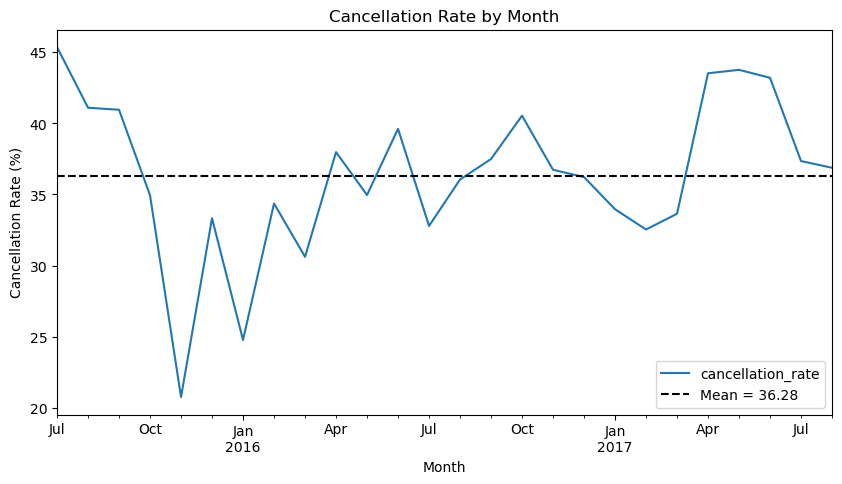

In [ ]:
# Checking % cancelation by month:
# - There is some sazonality pherraps, but it is stable during the period

df_plot.plot(
    x="date",
    y="cancellation_rate",
    figsize=(10, 5)
)

m = df_plot["cancellation_rate"].mean()
plt.axhline(
    m,
    linestyle="--",
    label=f"Mean = {m.round(2)}%",
    color="black"
)

plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")
plt.title("Cancellation Rate by Month")
plt.legend()
plt.show()